# DETECTION AND CLASSIFICATION OF DIABETIC RETINOPATHY THROUGH HEMORRHAGES USING CNN

# 1.Importing Libraries

In [1]:
import numpy as np #Used for numerical operations and handling arrays
import pandas as pd #Used for handling structured data like dataset in tabular format
import matplotlib.pyplot as plt #used for visualizing images,graphs,and data distributions
from sklearn.model_selection import train_test_split #splitting the dataset into training and testing sets
from sklearn.metrics import accuracy_score #Measuring model accuracy
from tensorflow.keras.preprocessing.image import ImageDataGenerator #Images data Augmentation
from tensorflow.keras.models import Sequential #Creating the CNN Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input #Importing Layers for CNN

In [2]:
import os
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #Evaluating Model Performance

# 2.FUNDUS IMAGES

## 2.1 Loading and Exploring the Dataset
### ~Reads Image from Two Categories(no_Hemorrhages,Hemorrhages).
### ~Converts them to grayscale and resizes the to 200x200.
### ~store the images in X & Y Lables.
### ~Provides a correct check to confirm the correct number of images and labels.

In [3]:
# Initialize lists to store images and labels
x = []
y = []

# Define classes and base directory
classes = {'no_Hemorrhages': 0, 'Hemorrhages': 1}
base_dir = r"C:\Users\gunan\OneDrive\Documents\Desktop\DR--"

# Load images and labels
for cls in classes:
    pth = os.path.join(base_dir, cls)
    if os.path.exists(pth):
        for j in os.listdir(pth):
            img_path = os.path.join(pth, j)
            img = cv2.imread(img_path, 0)  # Read image in grayscale
            img = cv2.resize(img, (200, 200))  # Resize to 200x200 pixels
            x.append(img)
            y.append(classes[cls])
    else:
        print(f"Directory {pth} does not exist")
print(f"Number of images: {len(x)}")
print(f"Number of labels: {len(y)}")

Number of images: 3292
Number of labels: 3292


## 2.2 Converting Data to NumPy Arrays and Checking Class Distribution

In [4]:
x = np.array(x)
y = np.array(y) #convert lists to NumPy Arrays
print(pd.Series(y).value_counts())  # Print class distribution

0    1805
1    1487
Name: count, dtype: int64


## 2.3 shows sample Image

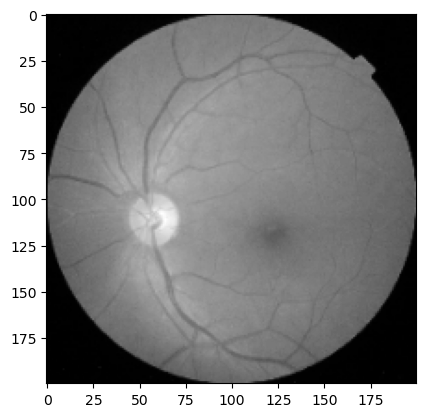

In [5]:
plt.imshow(x[0], cmap='gray')
plt.show()

# 3.CNN Model for Hemorrhages Classfication


In [6]:
# Define the CNN model
model = Sequential([
    Input(shape=(224, 224, 1)), #224*224 pixel grayscale image 
    Conv2D(32, (3, 3), activation='relu'), #32 filters of size 3*3 to the input image,relu-(linearity)
    MaxPooling2D(pool_size=(2, 2)),  
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(), #convert 2D layer to 1D layer
    Dense(128, activation='relu'), #fully conneted layer with 128 neurons.
    Dropout(0.5), #layers droup 50% of the neurons.
    Dense(1, activation='sigmoid')  # Binary classification ,sigmoid-
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
#adam is a efficient optimization algorithm 
#binary_crossentropy is suitable for binary classification problems.
#accuracy used for evaluate the model's performance.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,906,945 (91.20 MB)

 Trainable params: 23,906,945 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

# 4.Pre-processing and Model Training

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.model_selection import train_test_split

# Reshape x back to its original dimensions if known (e.g., 28x28 for MNIST, 1 channel for grayscale)
original_height, original_width = 200, 200  # Replace with actual height and width if different
x = x.reshape(len(x), original_height, original_width, 1)

# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=10, test_size=0.20)
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Function to preprocess and resize images
def preprocess_images(images):
    processed_images = []
    for img in images:
        resized_img = tf.image.resize(img, (224, 224)).numpy()  # Resize to (224, 224)
        processed_images.append(resized_img)
    return np.array(processed_images)

# Preprocess x_train and x_test
x_train_resized = preprocess_images(x_train)
x_test_resized = preprocess_images(x_test)
# Check new shape
print("Resized shape of x_train:", x_train_resized.shape)
print("Resized shape of x_test:", x_test_resized.shape)
# Step 2: Set up ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1, horizontal_flip=True)
datagen.fit(x_train_resized)
# Fit the model
history = model.fit(datagen.flow(x_train_resized, y_train, batch_size=32),  
                    epochs=5,
                    validation_data=(x_test_resized, y_test))

Resized shape of x_train: (2633, 224, 224, 1)
Resized shape of x_test: (659, 224, 224, 1)


C:\Users\gunan\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 683ms/step - accuracy: 0.7594 - loss: 0.6551 - val_accuracy: 0.8786 - val_loss: 0.2443
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 57s 685ms/step - accuracy: 0.8729 - loss: 0.2917 - val_accuracy: 0.8892 - val_loss: 0.2440
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 55s 662ms/step - accuracy: 0.8708 - loss: 0.3049 - val_accuracy: 0.8998 - val_loss: 0.2213
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 54s 644ms/step - accuracy: 0.8882 - loss: 0.2776 - val_accuracy: 0.8938 - val_loss: 0.2208
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 55s 657ms/step - accuracy: 0.8917 - loss: 0.2534 - val_accuracy: 0.9165 - val_loss: 0.2099


# 5.Confusion Matrix

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step


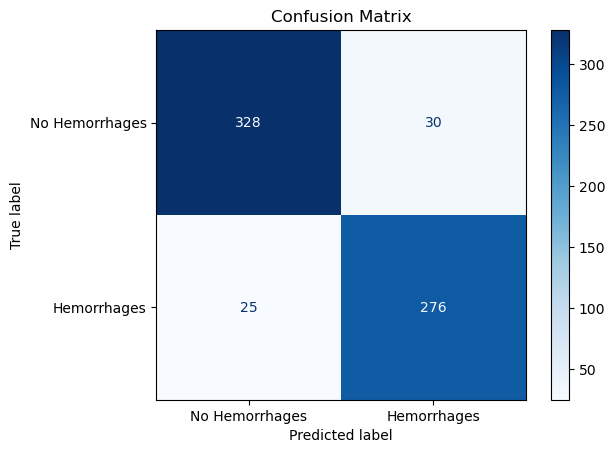

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on the test set
y_pred = model.predict(x_test_resized)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()  # Convert probabilities to binary classes

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Hemorrhages', 'Hemorrhages'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# 6.Epoches Curve(Training and Validation Accuracy)

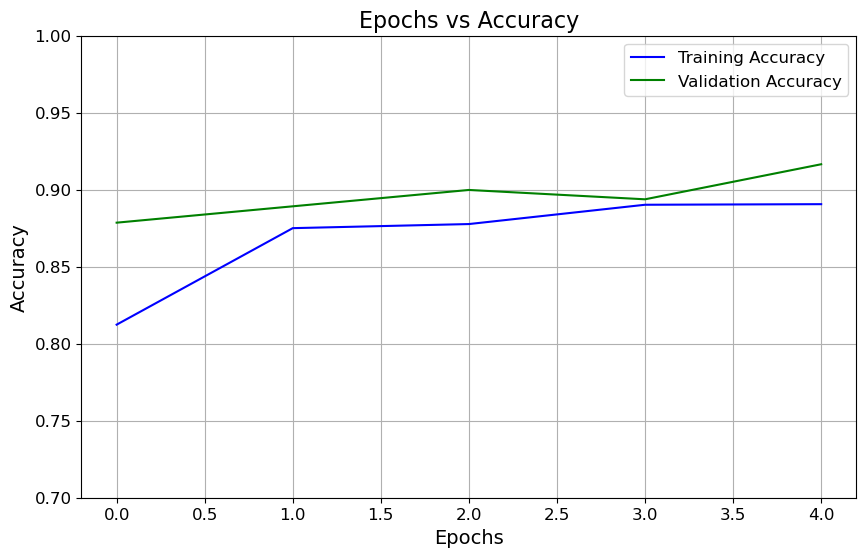

In [9]:
# Import necessary libraries
import matplotlib.pyplot as plt
# Extract accuracy values from history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
# Plot accuracy for training and validation
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy, label='Training Accuracy', color='blue')
plt.plot(val_accuracy, label='Validation Accuracy', color='green')
# Set y-axis range between 0.70 and 1.0
plt.ylim(0.70, 1.0)
# Add plot details
plt.title('Epochs vs Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
# Display plot
plt.show()

# 7.Uploading

FileUpload(value=(), accept='image/*', description='Upload')

Image uploaded successfully!


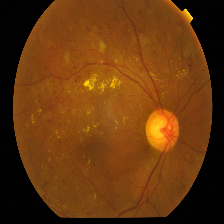

In [66]:
import ipywidgets as widgets
from PIL import Image
from io import BytesIO
from IPython.display import display

# Global variable to store the uploaded image (original, unprocessed)
uploaded_image = None

# Create file upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',  # Accept image files only
    multiple=False  # Only allow one file at a time
)

# Function to handle file selection
def on_upload_change(change):
    global uploaded_image  # Store the original uploaded image
    if upload_widget.value:
        uploaded_file = next(iter(upload_widget.value))
        image_data = uploaded_file['content']
        uploaded_image = Image.open(BytesIO(image_data))  # Store the image but don't process it

        print("Image uploaded successfully!")
        
        # Display the uploaded image
        display(uploaded_image)

# Link the widget to the function
upload_widget.observe(on_upload_change, names='value')

# Display the upload widget
display(upload_widget)


# 8.Pre-Processing

## ~Grayscale Image
## ~Normalized Image
## ~Enhanced Image

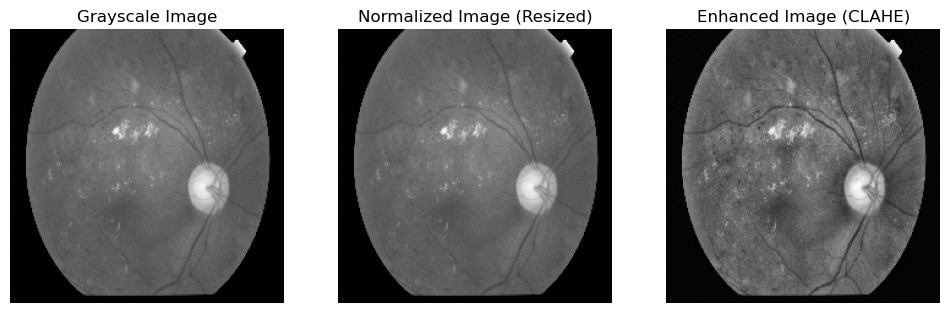

In [67]:
# Check if an image has been uploaded
if uploaded_image is not None:
    # Convert image to grayscale
    image_gray = np.array(uploaded_image.convert('L'))

    # Resize the grayscale image to 224x224
    image_resized = cv2.resize(image_gray, (224, 224))
    
    # Normalize the resized image
    image_normalized = image_resized / 255.0
    
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_enhanced = clahe.apply(image_resized)

    # Display the grayscale, resized (normalized), and enhanced images
    plt.figure(figsize=(12, 4))

    # Grayscale image
    plt.subplot(1, 3, 1)
    plt.imshow(image_resized, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')

    # Normalized image (resized)
    plt.subplot(1, 3, 2)
    plt.imshow(image_normalized, cmap='gray')
    plt.title("Normalized Image (Resized)")
    plt.axis('off')

    # Enhanced image (CLAHE)
    plt.subplot(1, 3, 3)
    plt.imshow(image_enhanced, cmap='gray')
    plt.title("Enhanced Image (CLAHE)")
    plt.axis('off')
    
    # Show all the images
    plt.show()

else:
    print("No image found. Please upload an image in the previous block.")


# 9.Optic Disk Removal

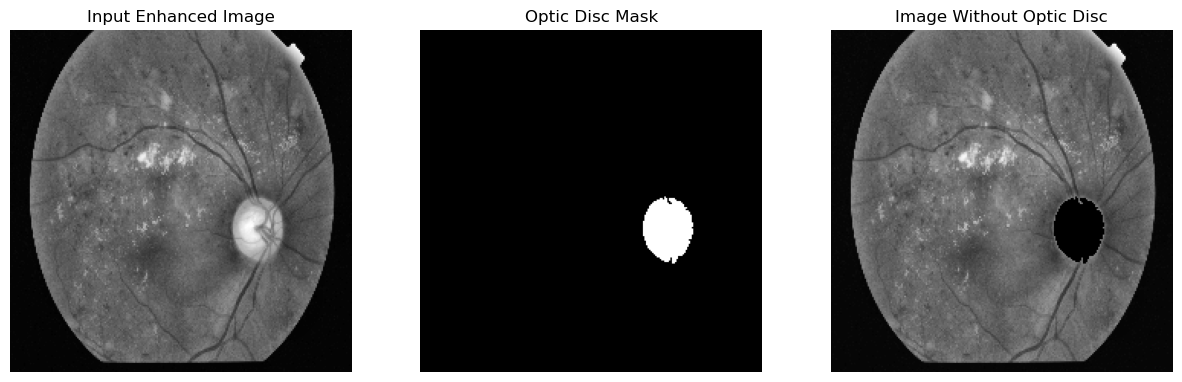

In [68]:
# Step: Remove Optic Disc
def remove_optic_disc(image):
    # Ensure the input image is valid
    if image is None or image.size == 0:
        print("Error: Input image is empty or not properly loaded.")
        return None
    
    # Detect the optic disc (brightest region)
    _, brightest_region = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY)

    # Find contours of the brightest region (optic disc)
    contours, _ = cv2.findContours(brightest_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Assume the largest contour corresponds to the optic disc
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(image, dtype=np.uint8)
        # Create a mask for the optic disc
        cv2.drawContours(mask, [largest_contour], -1, 255, thickness=-1)
        # Invert the mask for removal
        mask_inverted = cv2.bitwise_not(mask)
        # Remove the optic disc region from the image
        image_no_optic_disc = cv2.bitwise_and(image, image, mask=mask_inverted)
    else:
        print("Optic disc not detected.")
        return None
    
    # Display the results
    plt.figure(figsize=(15, 5))
    
    # Show the input enhanced image
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Input Enhanced Image")
    plt.axis('off')
    
    # Detected Optic Disc Mask
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Optic Disc Mask")
    plt.axis('off')
    
    # Image Without Optic Disc
    plt.subplot(1, 3, 3)
    plt.imshow(image_no_optic_disc, cmap='gray')
    plt.title("Image Without Optic Disc")
    plt.axis('off')
    
    plt.show()
    
    return image_no_optic_disc

# Assuming 'image_enhanced' is available after CLAHE enhancement
if image_enhanced is not None:
    optic_disc_removed = remove_optic_disc(image_enhanced)
else:
    print("Error: 'image_enhanced' is not available.")

# 10.Segmentation

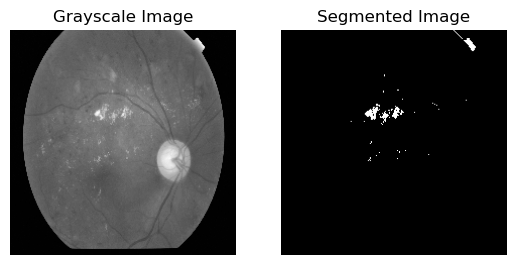

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to enhance bright regions using CLAHE
def enhance_bright_regions(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(image)
    return enhanced_image

# Function to remove optic disc and optic cup
def remove_optic_disc_and_cup(image):
    if image is None or image.size == 0:
        print("Error: Input image is empty or not properly loaded.")
        return None
    
    # Enhance the image for better optic disc and cup detection
    enhanced_image = enhance_bright_regions(image)

    # Detect the brightest region (optic disc) using intensity threshold
    _, brightest_region = cv2.threshold(enhanced_image, 120, 255, cv2.THRESH_BINARY)

    # Find contours of the brightest region (optic disc)
    contours, _ = cv2.findContours(brightest_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Assuming the largest contour corresponds to the optic disc
        largest_contour = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(image, dtype=np.uint8)
        cv2.drawContours(mask, [largest_contour], -1, 255, thickness=-1)
        
        # Darken the optic disc region
        image_no_optic_disc = cv2.bitwise_and(image, image, mask=~mask)
        
        # Further refine the removal process for the optic cup
        # Assuming the optic cup is a smaller region inside the optic disc
        # You may need to adjust this process based on your image characteristics
        _, cup_region = cv2.threshold(enhanced_image, 150, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(cup_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            cup_mask = np.zeros_like(image, dtype=np.uint8)
            cv2.drawContours(cup_mask, [largest_contour], -1, 255, thickness=-1)
            image_no_optic_disc_and_cup = cv2.bitwise_and(image_no_optic_disc, image_no_optic_disc, mask=~cup_mask)
        else:
            print("Optic cup not detected.")
            image_no_optic_disc_and_cup = image_no_optic_disc
    else:
        print("Optic disc not detected.")
        return None
    
    return image_no_optic_disc_and_cup

# Function to apply thresholding
def threshold_image(image):
    if image is None or image.size == 0:
        print("Error: Input image is empty or not properly loaded.")
        return

    # Convert to grayscale if not already
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        image_gray = image

    # Apply global thresholding
    _, binary_image = cv2.threshold(image_gray, 127, 255, cv2.THRESH_BINARY)

    # Apply adaptive thresholding
    adaptive_binary_image = cv2.adaptiveThreshold(
        image_gray,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=11,
        C=2
    )
    
    
    plt.subplot(1, 2, 1)
    plt.imshow(image_resized, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(binary_image, cmap='gray')
    plt.title("Segmented Image")
    plt.axis('off')
    plt.show()
    
    return binary_image

# Assuming 'image_resized' is the resized and normalized input image
if image_resized is not None:
    image_no_optic_disc_and_cup = remove_optic_disc_and_cup(image_resized)
    if image_no_optic_disc_and_cup is not None:
        binary_result = threshold_image(image_no_optic_disc_and_cup)
else:
    print("Error: 'image_resized' is not available.")

In [70]:
# Prepare the image for model prediction
image_input = np.expand_dims(image_normalized, axis=(0, -1))  # Adjust shape for model input

# Make a prediction
prediction = model.predict(image_input)
class_label = 'Active Hemorrhages' if prediction > 0.5 else 'No Hemorrhages'

# Print the prediction result as a text message
print(f"Prediction: {class_label}")

AttributeError: 'str' object has no attribute 'predict'

# 11.ROC Curve

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step


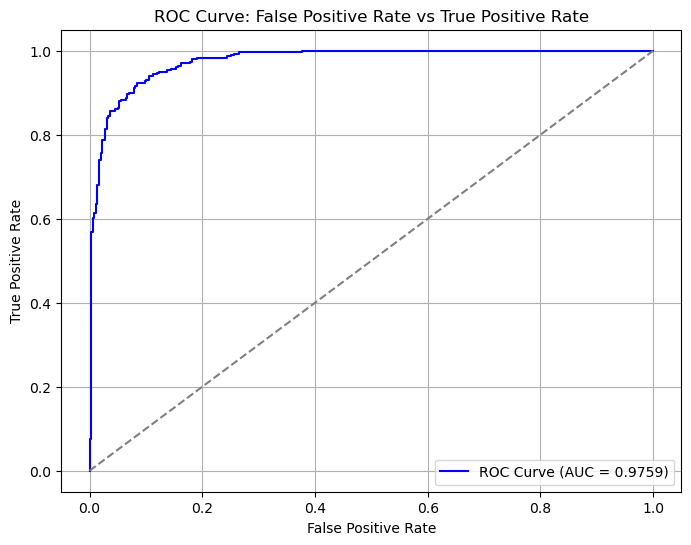

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the predicted probabilities for the test set
y_test_pred_prob = model.predict(x_test_resized)

# Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_prob)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')  # ROC curve
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line (no discrimination)
plt.title('ROC Curve: False Positive Rate vs True Positive Rate')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 12.Accuracy for CNN Model

In [16]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_test_pred = model.predict(x_test_resized)

# Convert predicted probabilities to binary class labels (e.g., threshold = 0.5)
y_test_pred_bin = (y_test_pred > 0.5).astype(int)  # Converts probabilities to 0 or 1

# Calculate accuracy
accuracy = accuracy_score(y_test, y_test_pred_bin)
print(f'Accuracy: {accuracy * 100:.2f}%')

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step
Accuracy: 91.65%


# 13.Classification Report
## Precision,Recall,F1-score,Support

In [17]:
from sklearn.metrics import classification_report

# After fitting the model, predict the results for both training/validation and testing datasets
y_train_pred = model.predict(x_train_resized)  # Training set predictions
y_test_pred = model.predict(x_test_resized)    # Test set predictions

# Convert predictions to binary (if necessary, depending on your model's output)
y_train_pred = (y_train_pred > 0.5).astype(int)  # Assuming the model outputs probabilities
y_test_pred = (y_test_pred > 0.5).astype(int)

# Classification report for Training Set
print("Classification Report for Training Set:")
print(classification_report(y_train, y_train_pred))

# Classification report for Test Set
print("Classification Report for Test Set:")
print(classification_report(y_test, y_test_pred))


83/83 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step
Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1447
           1       0.92      0.88      0.90      1186

    accuracy                           0.91      2633
   macro avg       0.91      0.91      0.91      2633
weighted avg       0.91      0.91      0.91      2633

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       358
           1       0.90      0.92      0.91       301

    accuracy                           0.92       659
   macro avg       0.92      0.92      0.92       659
weighted avg       0.92      0.92      0.92       659



# 14.Comparing CNN model with SVM,Random Forest,Decision Tree

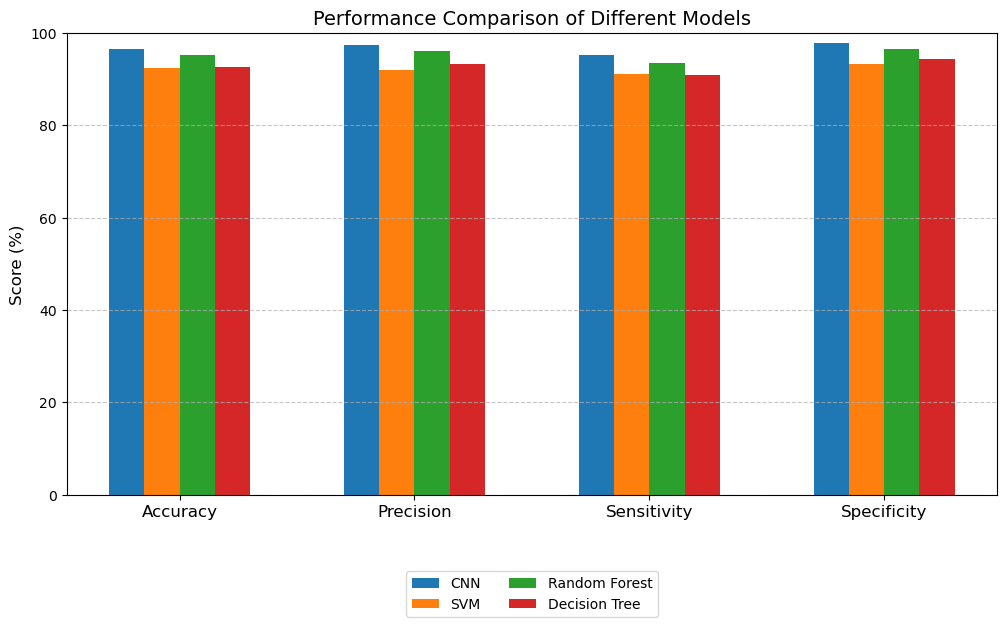

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Given values for different models (excluding Naive Bayes and Logistic Regression)
models = {
    "CNN": {'TP': 293, 'TN': 343, 'FP': 8, 'FN': 15},
    "SVM": {'TP': 277, 'TN': 331, 'FP': 24, 'FN': 27},
    "Random Forest": {'TP': 289, 'TN': 338, 'FP': 12, 'FN': 20},
    "Decision Tree": {'TP': 277, 'TN': 330, 'FP': 20, 'FN': 28}
}

# Define metrics
metrics = ["Accuracy", "Precision", "Sensitivity", "Specificity"]
num_metrics = len(metrics)
model_names = list(models.keys())

# Compute values for each metric
metrics_values = {metric: [] for metric in metrics}

for model, vals in models.items():
    TP, TN, FP, FN = vals['TP'], vals['TN'], vals['FP'], vals['FN']
    metrics_values["Accuracy"].append((TP + TN) / (TP + TN + FP + FN) * 100)
    metrics_values["Precision"].append((TP / (TP + FP) * 100) if (TP + FP) != 0 else 0)
    metrics_values["Sensitivity"].append((TP / (TP + FN) * 100) if (TP + FN) != 0 else 0)
    metrics_values["Specificity"].append((TN / (TN + FP) * 100) if (TN + FP) != 0 else 0)

# Define bar width
bar_width = 0.15
x = np.arange(num_metrics)  # X-axis positions for metrics

plt.figure(figsize=(12, 6))

# Plot bars for each model
for i, model in enumerate(model_names):
    plt.bar(x + i * bar_width, [metrics_values[metric][i] for metric in metrics], bar_width, label=model)

# Set labels and ticks
plt.xticks(x + bar_width * (len(models) - 1) / 2, metrics, fontsize=12)  # X-axis labels (metrics)
plt.ylim(0, 100)  # Set Y-axis range from 0 to 100
plt.ylabel("Score (%)", fontsize=12)
plt.title("Performance Comparison of Different Models", fontsize=14)

# Move legend to bottom
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10)

# Grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()